# Vol 21 — Joint SPX/VIX Models

**問い:** SPX smileとVIX term structureを一つの状態モデルで同時に説明できるか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

4-factor PDVを主モデル、AFV・rough-Heston kernel・quintic OUを比較に置く。SPX IV、VIX、variance termを別metricでjoint objectiveへ渡し、nested teacherとsurrogateの誤差・速度を併記する。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'joint_surface.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 21
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=21 digest=f90b57db8af98ea9 arrays=38


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

in_domain_greek_rmse: 25.349173063933875
in_domain_price_rmse: 0.4256623957319136
joint_spx_rmse: 0.03640612872286824
joint_variance_rmse: 0.012136360789840171
joint_vix_option_rmse: 1.7147112919089407
joint_vix_rmse: 4.139354595392237
ood_count: 4
ood_greek_rmse: 25.41046863034563
ood_price_rmse: 0.3381758958670694
surrogate_delta_rmse: 5.043078088519851
surrogate_gamma_rmse: 35.50726161092219
surrogate_greek_rmse: 25.359399280280453
surrogate_price_rmse: 0.4123722655252687
surrogate_speedup_1024: 914.2897131825704
teacher: hullkit.spx_vix.nested_vix_teacher
timing_method: perf_counter_ns warm-cache median of 5
timing_nondeterministic: True


## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS joint_model_ladder 4 exact four-model ladder with all joint components
PASS teacher_surrogate_pairing True price/delta/gamma shapes match
PASS teacher_uncertainty 16 aligned, nonnegative, and nontrivial standard errors
PASS ood_shell 4 > 0 flagged observations
PASS measured_cpu_timing perf_counter_ns warm-cache median of 5 positive measured samples
PASS surrogate_speedup 914.2897131825704 > 1 at batch 1024
PASS joint_objective_components True all four component errors finite
PASS in_domain_ood_diagnostics True price and Greek RMSE finite in both domains


## SPX IV joint fit

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

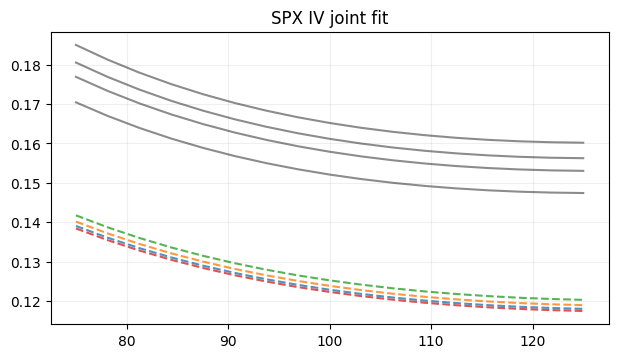

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("SPX IV joint fit")
for i in range(data["spx_target"].shape[0]):
    ax.plot(data["strike"], data["spx_target"][i], color="black", alpha=.45)
    ax.plot(data["strike"], data["spx_pdv"][i], linestyle="--", alpha=.8)
ax.grid(alpha=.2)
plt.show()

## VIX term structure

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

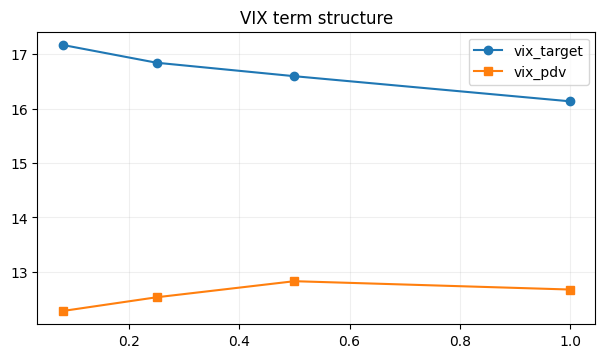

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("VIX term structure")
ax.plot(data["vix_maturity"], data["vix_target"], marker="o", label="vix_target")
ax.plot(data["vix_maturity"], data["vix_pdv"], marker="s", label="vix_pdv")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## PDV/AFV/rough/quintic比較

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


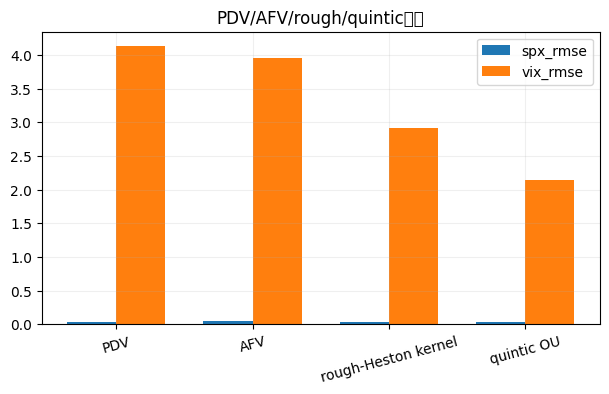

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("PDV/AFV/rough/quintic比較")
x = np.arange(len(data["model_names"]))
ax.bar(x - .18, data["spx_rmse"], width=.36, label="spx_rmse")
ax.bar(x + .18, data["vix_rmse"], width=.36, label="vix_rmse")
ax.set_xticks(x, data["model_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## nested MC vs surrogate

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

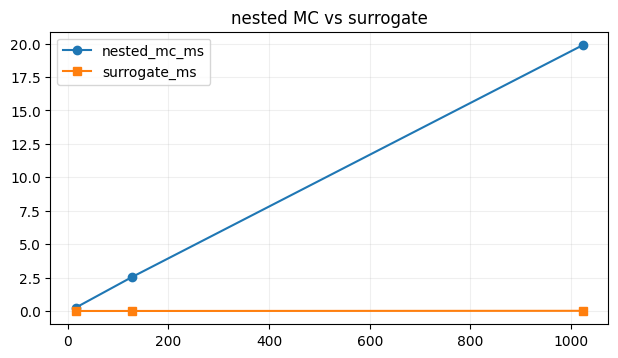

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("nested MC vs surrogate")
ax.plot(data["batch_size"], data["nested_mc_ms"], marker="o", label="nested_mc_ms")
ax.plot(data["batch_size"], data["surrogate_ms"], marker="s", label="surrogate_ms")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [8]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Guyon & Lekeufack (2023), Path-dependent volatility; Bergomi (2016), Stochastic Volatility Modeling.

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。